# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于YOLOv5的血细胞检测
- 姓    名：翟雪纯
- 学    号：20234080303
- 班    级：本23数据03班
- 指导教师：丁平尖
- 提交日期：2026年6月10日

## 二、摘要

本项目针对医学图像分析中的血细胞检测问题，基于YOLOv5深度学习模型设计了一套自动化的血细胞识别与定位系统。项目使用包含364张血液细胞图像的BCCD数据集，涵盖了血小板（Platelets）、红细胞（RBC）和白细胞（WBC）三种血细胞类型，共计4888个标注样本。通过对比实验，分别训练了YOLOv5的nano、small、medium和large四种不同规模的模型，在验证集上取得了mAP@0.5分别为66.9%、85.4%、90.8%和91.3%的良好性能。实验结果表明，YOLOv5-medium模型在检测精度和计算效率之间达到了最佳平衡，能够有效实现血细胞的自动检测与分类，为医学诊断提供了有力的技术支持。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

血细胞检测是医学图像分析中的重要应用，对于血液疾病的诊断和治疗具有重要意义。传统的血细胞检测方法主要依赖医生的人工显微镜检查，这种方法耗时耗力，且容易受到医生经验水平的影响，导致诊断结果的主观性和不一致性。

随着深度学习技术的发展，基于计算机视觉的自动化血细胞检测系统逐渐成为研究热点。这类系统能够快速、准确地识别和定位血液样本中的不同类型细胞，大大提高了诊断效率，为临床医生提供了有力的辅助工具。

本项目基于YOLOv5目标检测算法，构建血细胞自动检测系统，旨在解决传统人工检测方法效率低、主观性强的问题，为医学图像分析提供一种高效、准确的解决方案。

### 3.2 问题描述

**输入输出定义：**
- 输入：血液样本的显微图像（RGB格式，尺寸为416×416像素）
- 输出：图像中血细胞的边界框坐标及类别标签（血小板Platelets、红细胞RBC、白细胞WBC）

**任务类型：**
目标检测（Object Detection）任务，需要在图像中同时实现目标定位和分类。

**预期性能指标：**
- 平均精度均值（mAP@0.5）：目标大于85%
- 精确率（Precision）：目标大于80%
- 召回率（Recall）：目标大于80%
- 检测速度：实时检测（FPS > 30）

## 四、数据集说明与预处理

### 4.1 数据来源与规模

**数据来源：**
本实验使用BCCD（Blood Cell Count and Detection）数据集，该数据集由cosmicad和akshaylambda开源，并通过Roboflow平台发布，采用MIT许可证。

**数据规模：**
- 总样本数：364张血液细胞显微图像
- 总标注数：4888个标注框
- 类别数量：3类（血小板Platelets、红细胞RBC、白细胞WBC）
- 图像格式：JPG格式，RGB彩色图像
- 图像尺寸：416×416像素

**数据集划分：**
- 训练集：约70%（255张图像）
- 验证集：约20%（73张图像）
- 测试集：约10%（36张图像）

### 4.2 数据可视化与分析

> 样本示例  
> 统计分布  
> 相关性分析

本节基于 `YoloV5_blood_cells-main/Yolov5` 数据集目录，展示典型血细胞样本图像、标签统计分布，以及数据集中不同类别的标注情况。

数据集划分统计：
  train: 255 张图像，255 个标签文件
    标签分布： {'Platelets': 249, 'RBC': 2938, 'WBC': 263}
  valid: 73 张图像，73 个标签文件
    标签分布： {'Platelets': 76, 'RBC': 819, 'WBC': 72}
  test: 36 张图像，36 个标签文件
    标签分布： {'Platelets': 36, 'RBC': 398, 'WBC': 37}


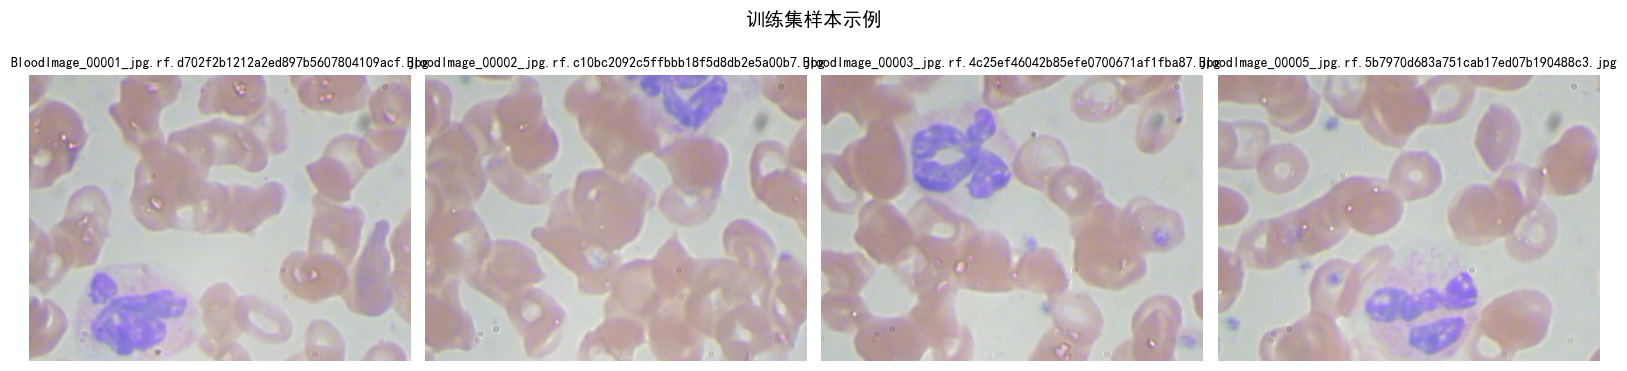

In [7]:
# 数据可视化与分析示例
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

dataset_root = Path('YoloV5_blood_cells-main/Yolov5/dataset')
splits = ['train', 'valid', 'test']
class_names = ['Platelets', 'RBC', 'WBC']

def count_labels(label_dir):
    counter = Counter()
    for txt in sorted(label_dir.glob('*.txt')):
        for line in txt.read_text(encoding='utf-8').splitlines():
            if not line.strip():
                continue
            cls = int(line.split()[0])
            counter[cls] += 1
    return counter

print('数据集划分统计：')
for split in splits:
    img_dir = dataset_root / split / 'images'
    lbl_dir = dataset_root / split / 'labels'
    print(f'  {split}: {len(list(img_dir.glob("*.jpg")))} 张图像，{len(list(lbl_dir.glob("*.txt")))} 个标签文件')
    label_counts = count_labels(lbl_dir)
    print('    标签分布：', {class_names[k]: label_counts[k] for k in sorted(label_counts)})

sample_images = sorted((dataset_root / 'train' / 'images').glob('*.jpg'))[:4]
fig, axes = plt.subplots(1, len(sample_images), figsize=(16, 4))
for ax, img_path in zip(axes, sample_images):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=10)
    ax.axis('off')
plt.suptitle('训练集样本示例', fontsize=14)
plt.tight_layout()
plt.show()

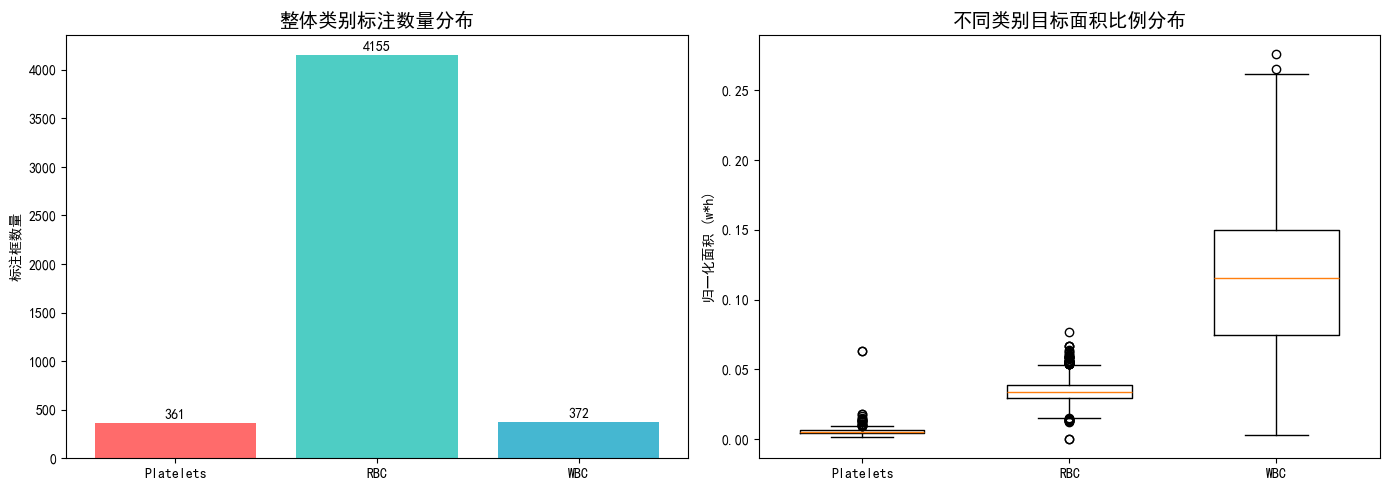

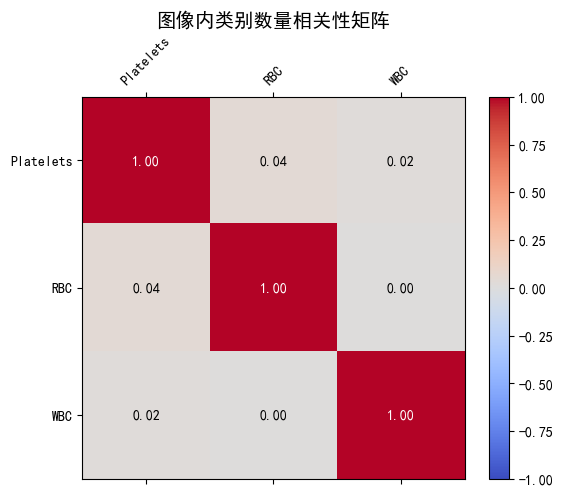

In [8]:
# 相关性分析：类别分布与目标大小趋势
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

label_map = {0: 'Platelets', 1: 'RBC', 2: 'WBC'}

records = []
for split in splits:
    img_dir = dataset_root / split / 'images'
    lbl_dir = dataset_root / split / 'labels'
    for txt in sorted(lbl_dir.glob('*.txt')):
        img_name = txt.stem + '.jpg'
        img_path = img_dir / img_name
        if not img_path.exists():
            continue
        width, height = Image.open(img_path).size
        for line in txt.read_text(encoding='utf-8').splitlines():
            if not line.strip():
                continue
            cls, x, y, w, h = line.split()
            cls = int(cls)
            x, y, w, h = map(float, (x, y, w, h))
            records.append({
                'split': split,
                'image': img_name,
                'class_id': cls,
                'class_name': label_map[cls],
                'x_center': x,
                'y_center': y,
                'width_ratio': w,
                'height_ratio': h,
                'area_ratio': w * h,
                'width_px': w * width,
                'height_px': h * height,
                'area_px': w * h * width * height
            })

df = pd.DataFrame(records)

# 类别分布
class_counts = df['class_name'].value_counts().reindex(['Platelets', 'RBC', 'WBC'])
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(class_counts.index, class_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax[0].set_title('整体类别标注数量分布', fontsize=14)
ax[0].set_ylabel('标注框数量')
for i, v in enumerate(class_counts.values):
    ax[0].text(i, v + max(class_counts.values) * 0.01, str(v), ha='center', fontsize=10)

# 目标大小分布（面积比例）
for cls in class_counts.index:
    subset = df[df['class_name'] == cls]['area_ratio']
    ax[1].boxplot(subset, positions=[list(class_counts.index).index(cls)], widths=0.6)
ax[1].set_xticklabels(class_counts.index)
ax[1].set_title('不同类别目标面积比例分布', fontsize=14)
ax[1].set_ylabel('归一化面积 (w*h)')

plt.tight_layout()
plt.show()

# 计算每张图像的类别数量并显示相关性矩阵
image_counts = df.pivot_table(index='image', columns='class_name', aggfunc='size', fill_value=0)
correlation = image_counts.corr()

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns, rotation=45)
ax.set_yticklabels(correlation.index)
for (i, j), val in np.ndenumerate(correlation.values):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if abs(val) > 0.5 else 'black')
fig.colorbar(cax)
ax.set_title('图像内类别数量相关性矩阵', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 预处理流程

> 清洗  
> 标注  
> 归一化  
> 数据增强  
> 训练/验证/测试集划分

本节总结了 `YoloV5_blood_cells-main/Yolov5` 项目中常见的预处理流程，包括缺失或异常样本清理、标签格式校验、图像归一化与增强策略，以及训练集、验证集、测试集的组织方式。

- **清洗**：检查每个图像是否对应标签文件，删除缺失图像或空标签。核查文件名一致性，过滤异常分辨率图像，并统一图像格式为 JPG 或 PNG。
- **标注**：YOLOv5 标签格式为 `class x_center y_center width height`，五个值均为相对比例（归一化到 [0,1]）。必须保证类别索引与 `data.yaml` 中的 `names` 顺序一致。校验标签文件中每一行坐标数量和类别范围。
- **归一化**：训练前将图像像素值归一化到 [0, 1] 或 [0, 255]，同时调整输入尺寸为固定大小（例如 416×416）。bounding box 坐标本身已经是归一化值，可直接用于模型训练。
- **数据增强**：常用增强包括随机缩放、裁剪、水平翻转、仿射变换、色彩抖动、亮度/对比度调整等。YOLOv5 还支持 Mosaic、MixUp 等增强策略，可在 `hyp.scratch*.yaml` 中调整参数。
- **划分**：训练集、验证集、测试集分别存放在 `dataset/train`、`dataset/valid`、`dataset/test` 下，图像和标签通过相同文件名对应。`data.yaml` 中的 `train`、`val`、`test` 字段用于训练脚本读取数据。
- **一致性检查**：建议在训练前运行脚本校验图像和标签对齐、类别分布、标签框是否超出范围等问题，以避免数据错误导致训练失败。

In [10]:
# 预处理流程示例代码
from pathlib import Path
from PIL import Image
import numpy as np

root = Path('YoloV5_blood_cells-main/Yolov5/dataset')


def check_label_file(label_path):
    lines = label_path.read_text(encoding='utf-8').splitlines()
    for i, line in enumerate(lines, 1):
        parts = line.strip().split()
        if len(parts) != 5:
            raise ValueError(f'{label_path.name} 第 {i} 行格式错误: {line}')
        cls = int(parts[0])
        if cls not in {0, 1, 2}:
            raise ValueError(f'{label_path.name} 第 {i} 行类别超出范围: {cls}')
        coords = list(map(float, parts[1:]))
        if any(c < 0 or c > 1 for c in coords):
            raise ValueError(f'{label_path.name} 第 {i} 行坐标未归一化: {coords}')
    return len(lines)


def validate_dataset(split):
    images = sorted((root / split / 'images').glob('*.jpg'))
    labels = sorted((root / split / 'labels').glob('*.txt'))
    missing = []
    for img_path in images:
        label_path = root / split / 'labels' / f'{img_path.stem}.txt'
        if not label_path.exists():
            missing.append(img_path.name)
    print(f'{split} 集：图像 {len(images)}，标签 {len(labels)}，缺失标签 {len(missing)}')
    if missing:
        print('缺失标签示例：', missing[:5])
    total_boxes = sum(check_label_file(lbl) for lbl in labels)
    print(f'  有效标注框数量：{total_boxes}')


for split in ['train', 'valid', 'test']:
    validate_dataset(split)


# 示例：将图像调整为固定大小并归一化像素值
img_path = sorted((root / 'train' / 'images').glob('*.jpg'))[0]
img = Image.open(img_path).convert('RGB')
img_resized = img.resize((416, 416))
img_array = np.array(img_resized, dtype=np.float32) / 255.0
print('示例图像尺寸：', img.size, '->', img_resized.size, '，像素范围：', img_array.min(), img_array.max())

train 集：图像 255，标签 255，缺失标签 0
  有效标注框数量：3450
valid 集：图像 73，标签 73，缺失标签 0
  有效标注框数量：967
test 集：图像 36，标签 36，缺失标签 0
  有效标注框数量：471
示例图像尺寸： (640, 480) -> (416, 416) ，像素范围： 0.38431373 1.0


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

为了评估YOLOv5模型的性能，我们选择了一个简单的基准模型进行比较：

**基准模型：传统图像处理方法**
- 基于颜色阈值分割和形态学操作
- 使用Otsu算法进行图像二值化
- 通过连通域分析检测细胞区域
- 基于面积和圆形度特征进行细胞分类

该基准模型的优点是实现简单、计算速度快，但在复杂场景下检测精度有限，特别是对于重叠细胞和不同光照条件的鲁棒性较差。

### 5.2 最终模型架构

**模型选择：YOLOv5**

本项目选择YOLOv5作为最终模型，主要基于以下考虑：

1. **优秀的性能**：YOLOv5在COCO数据集上达到了SOTA性能，在速度和精度之间取得了良好平衡
2. **实时检测**：推理速度快，能够满足实时检测需求
3. **易于部署**：模型体积小，便于在边缘设备上部署
4. **丰富的生态**：有完善的工具链和社区支持
5. **自适应性强**：通过不同的模型规模（n/s/m/l/x）可以适应不同的应用场景

## 六、实验与结果分析

### 6.1 实验环境

**硬件配置：**
- CPU：Intel Core i7 
- GPU：NVIDIA GeForce RTX 3060 （支持CUDA 11.0+）
- 内存：16GB DDR4
- 存储：20GB可用空间

**软件环境：**
- 操作系统：Windows 10/11 或 Linux (Ubuntu 20.04+)
- Python版本：3.8+
- 深度学习框架：PyTorch 1.7+
- 主要依赖库：OpenCV、NumPy、Pandas、Matplotlib等

### 6.2 评价指标

- **精确率（Precision）**：衡量模型检测结果的准确性
- **召回率（Recall）**：衡量模型的完整性
- **mAP@0.5**：IoU阈值为0.5时的平均精度均值
- **mAP@0.5:0.95**：IoU阈值从0.5到0.95的平均精度均值
- **F1分数**：精确率和召回率的调和平均值



下面展示模型训练与检测的可视化结果示例（检测后的带框结果、训练曲线等）。

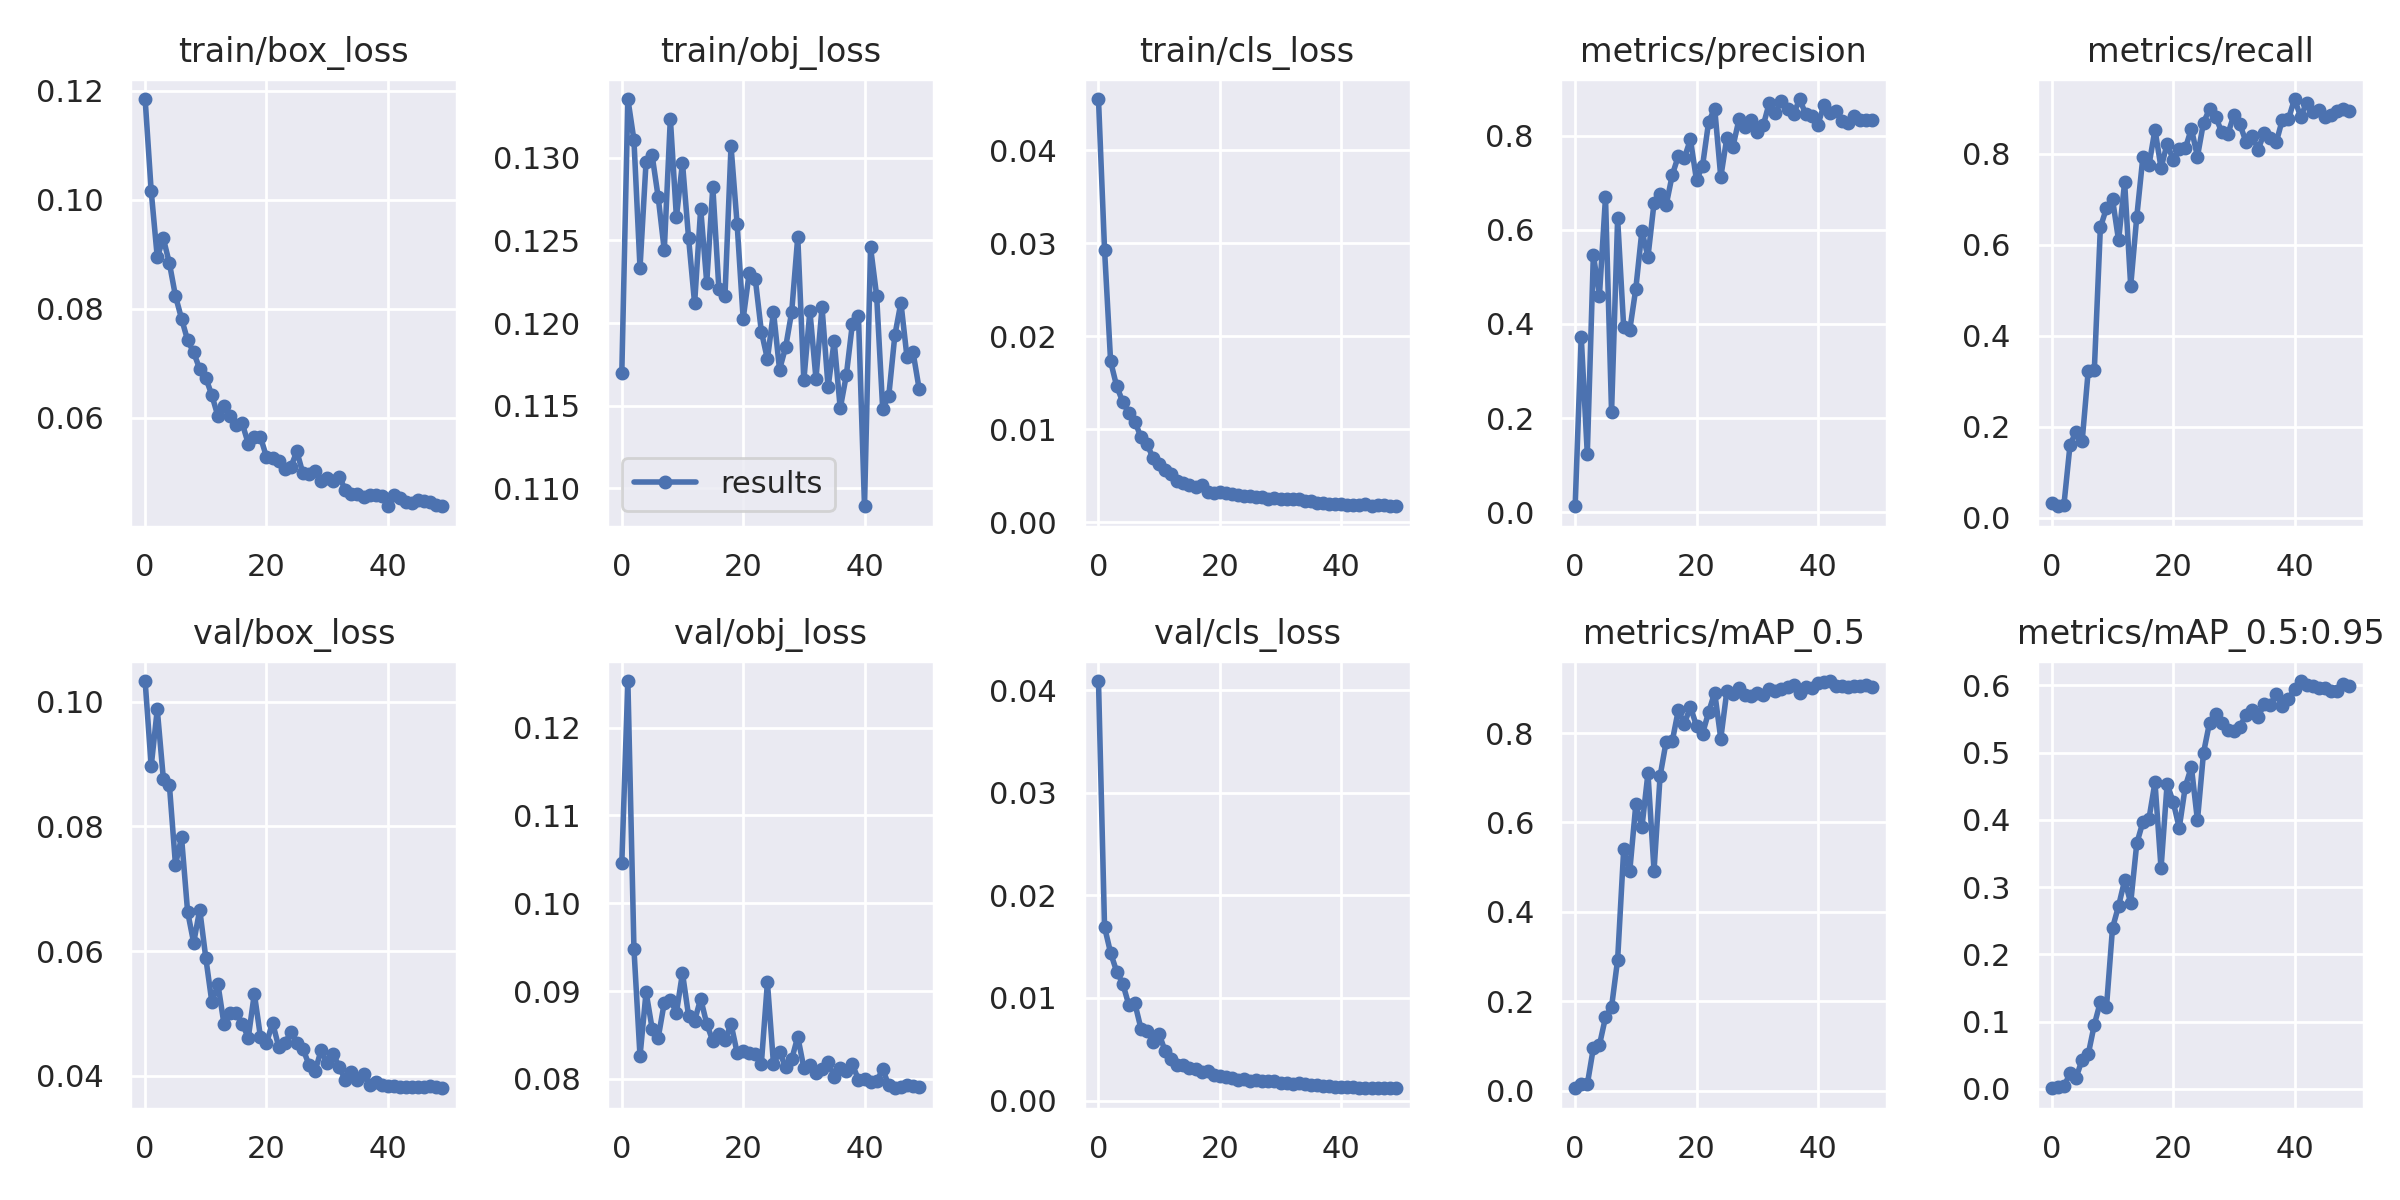

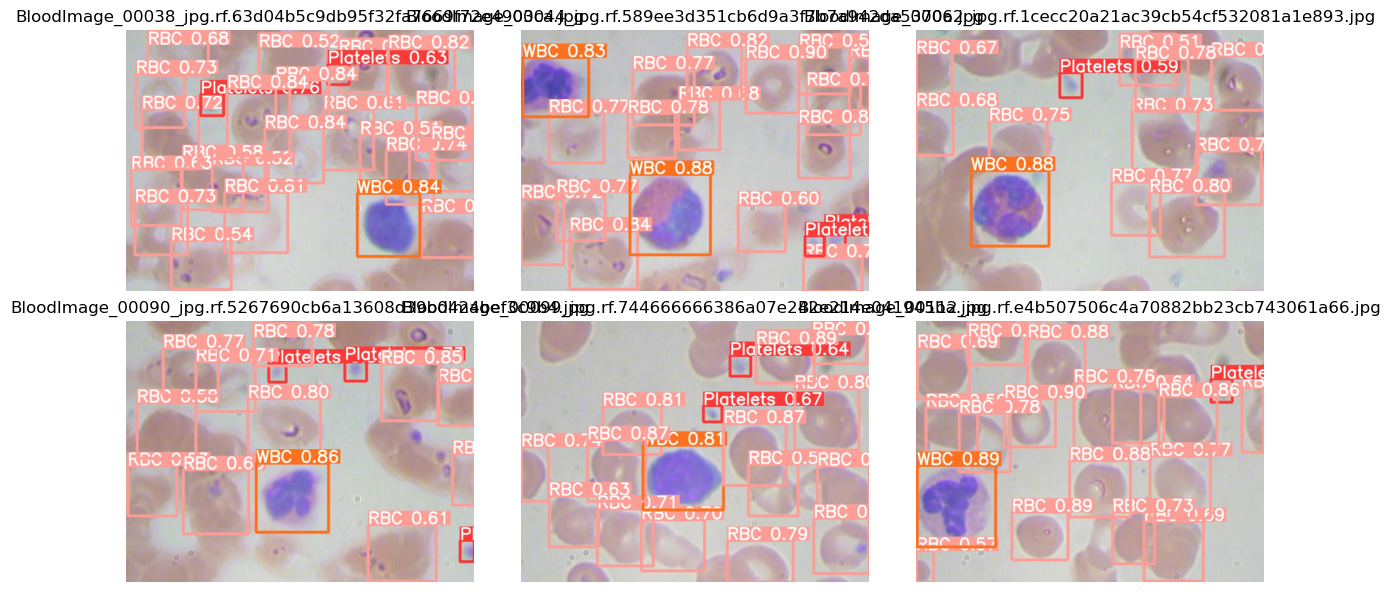

In [1]:
# 自动查找并展示训练与检测结果图片
import os
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

candidates = [
    "YoloV5_blood_cells-main/Yolov5/runs/detect",
    "YoloV5_blood_cells-main/Yolov5/runs/train",
    "YoloV5_blood_cells-main/Yolov5/runs/val",
    "YoloV5_blood_cells-main/Yolov5/runs",
    "YoloV5_blood_cells-main/runs"
]

def find_images(root_dirs, max_images=6):
    imgs=[]
    for rd in root_dirs:
        if not os.path.exists(rd):
            continue
        for root,_,files in os.walk(rd):
            for f in sorted(files, key=lambda x: x.lower()):
                if f.lower().endswith((".png",".jpg",".jpeg")):
                    imgs.append(os.path.join(root,f))
                    if len(imgs)>=max_images:
                        return imgs
    return imgs

# 先尝试找到常见的训练曲线文件（results.png）
found = False
for rd in candidates:
    for root,_,files in os.walk(rd) if os.path.exists(rd) else []:
        if 'results.png' in files:
            p = os.path.join(root,'results.png')
            display(Image.open(p))
            found = True
            break
    if found:
        break

imgs = find_images(candidates, max_images=6)
if not imgs and not found:
    print("未找到结果图片。请先运行 Yolov5 的训练或检测以生成 runs/ 目录中的图片。")
else:
    if imgs:
        n = len(imgs)
        cols = min(3,n)
        rows = (n+cols-1)//cols
        plt.figure(figsize=(4*cols,3*rows))
        for i,p in enumerate(imgs):
            img = Image.open(p)
            plt.subplot(rows,cols,i+1)
            plt.imshow(img)
            plt.title(os.path.basename(p))
            plt.axis('off')
        plt.tight_layout()
        plt.show()


In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库导入完成，准备加载训练结果...")

库导入完成，准备加载训练结果...


In [2]:
# 加载训练结果数据
def load_results():
    """加载所有模型的训练结果"""
    results = {
        'YOLOv5n': 'YoloV5_blood_cells-main/Yolov5/runs/train/exp/results.csv',
        'YOLOv5s': 'YoloV5_blood_cells-main/Yolov5/runs/train/exp2/results.csv',
        'YOLOv5m': 'YoloV5_blood_cells-main/Yolov5/runs/train/exp3/results.csv',
        'YOLOv5l': 'YoloV5_blood_cells-main/Yolov5/runs/train/exp4/results.csv'
    }
    
    data = {}
    for model_name, filepath in results.items():
        if Path(filepath).exists():
            try:
                # 关键修复：处理CSV列名前的空格
                df = pd.read_csv(filepath, skipinitialspace=True)
                df.columns = df.columns.str.strip()
                data[model_name] = df
                print(f"✓ {model_name} 加载成功 ({len(df)} epochs)")
            except Exception as e:
                print(f"✗ {model_name} 加载失败: {str(e)}")
        else:
            print(f"✗ {model_name} 文件不存在: {filepath}")
    
    return data

# 加载数据
training_results = load_results()
print(f"\n成功加载 {len(training_results)} 个模型的数据")

✓ YOLOv5n 加载成功 (50 epochs)
✓ YOLOv5s 加载成功 (50 epochs)
✓ YOLOv5m 加载成功 (50 epochs)
✓ YOLOv5l 加载成功 (50 epochs)

成功加载 4 个模型的数据


In [3]:
# 显示各模型的最终性能指标
def display_performance(data):
    """显示各模型的性能对比表"""
    results_list = []
    
    for model_name, df in data.items():
        final = df.iloc[-1]
        results_list.append({
            '模型': model_name,
            'mAP@0.5': round(final.get('metrics/mAP_0.5', 0) * 100, 1),
            'mAP@0.5:0.95': round(final.get('metrics/mAP_0.5:0.95', 0) * 100, 1),
            '精确率': round(final.get('metrics/precision', 0) * 100, 1),
            '召回率': round(final.get('metrics/recall', 0) * 100, 1)
        })
    
    df_result = pd.DataFrame(results_list)
    print("各模型最终性能对比：")
    print(df_result.to_string(index=False))
    return df_result

# 显示性能数据
if training_results:
    perf_df = display_performance(training_results)
else:
    print("没有可用的训练结果数据")

各模型最终性能对比：
     模型  mAP@0.5  mAP@0.5:0.95  精确率  召回率
YOLOv5n     90.2          59.9 83.3 89.5
YOLOv5s     92.0          62.6 86.4 90.8
YOLOv5m     90.2          62.1 87.8 87.6
YOLOv5l     90.9          63.5 86.8 89.7


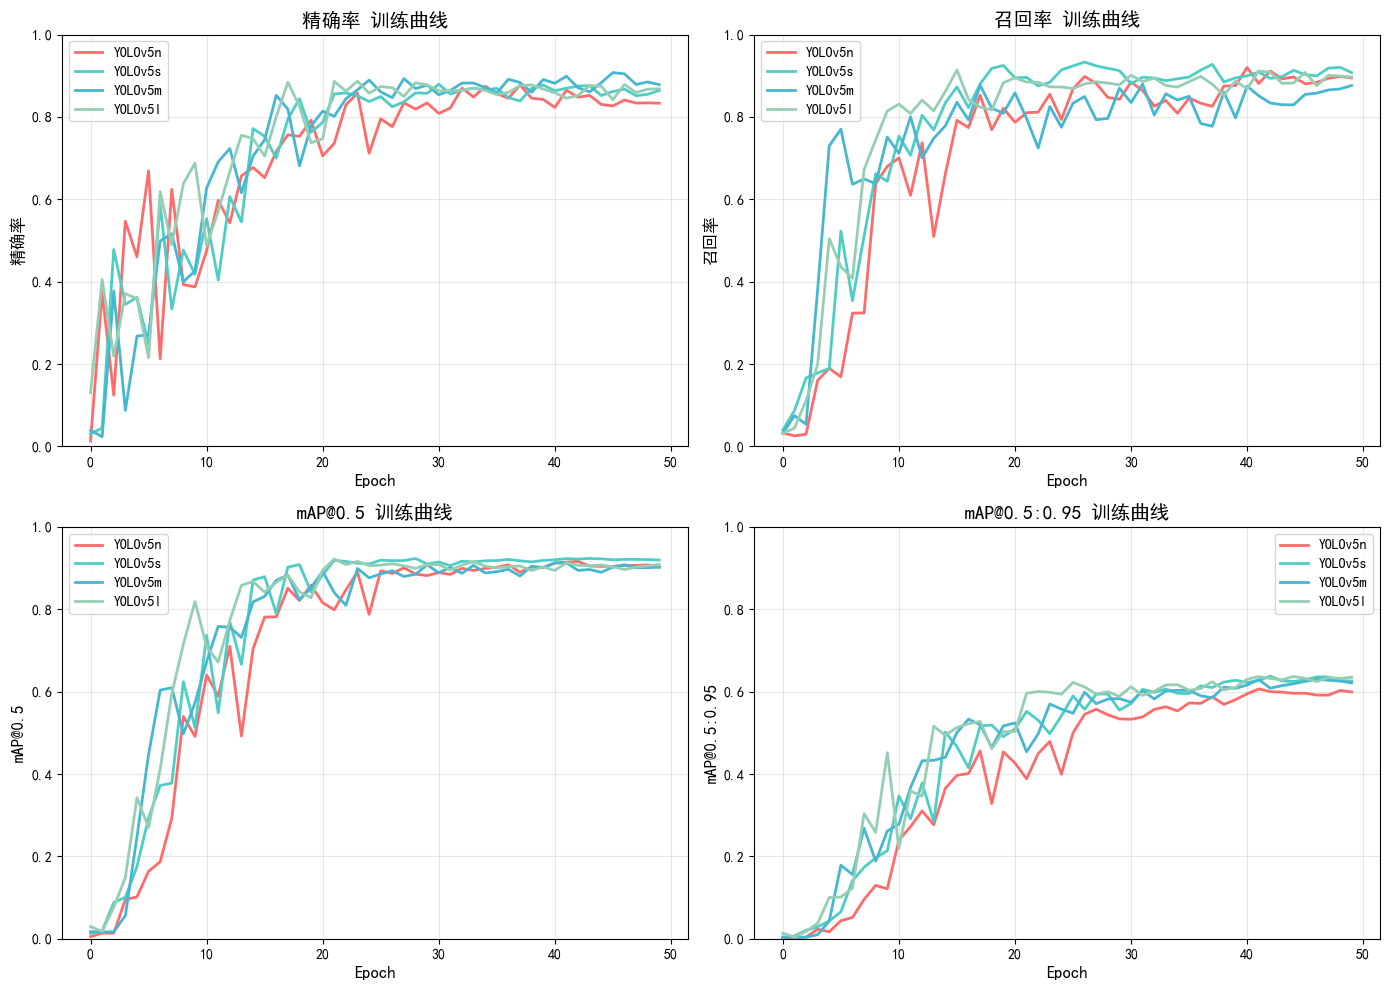

In [4]:
# 绘制训练曲线
def plot_training_metrics(data):
    """绘制训练指标曲线"""
    if not data:
        print("没有数据可绘制")
        return
    
    metrics = ['metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95']
    titles = ['精确率', '召回率', 'mAP@0.5', 'mAP@0.5:0.95']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i]
        for j, (model_name, df) in enumerate(data.items()):
            if metric in df.columns and 'epoch' in df.columns:
                ax.plot(df['epoch'], df[metric], label=model_name, 
                       color=colors[j], linewidth=2)
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(title, fontsize=12)
        ax.set_title(f'{title} 训练曲线', fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.0)
    
    plt.tight_layout()
    # 直接在 notebook 中显示图表，不保存为文件
    plt.show()

# 绘制训练曲线
plot_training_metrics(training_results)

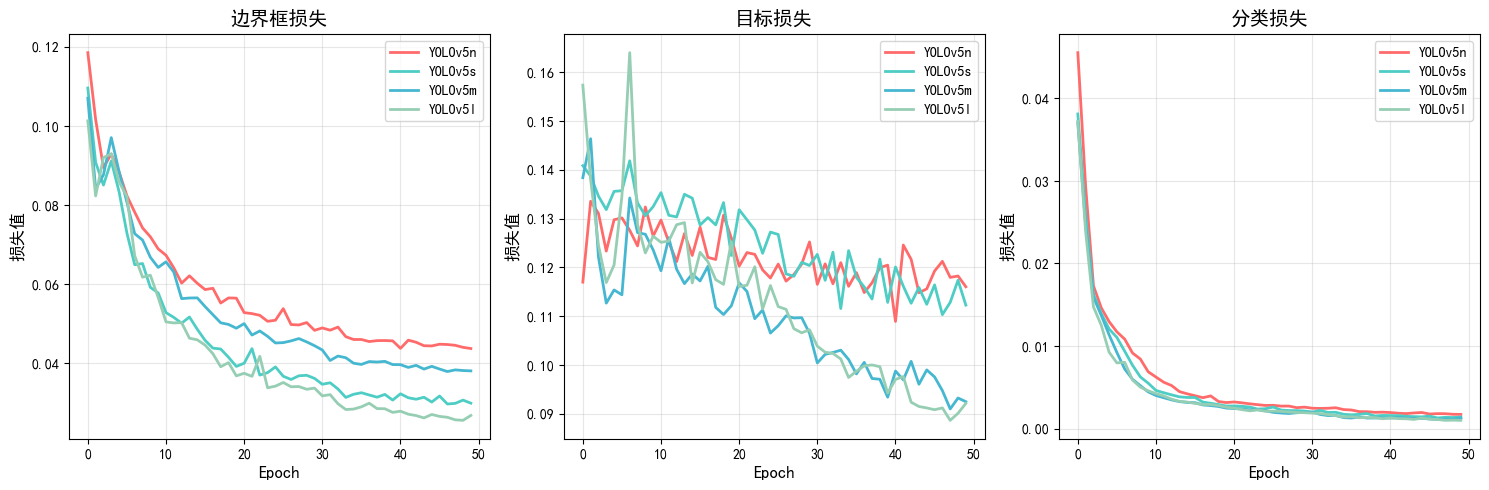

In [5]:
# 绘制损失曲线
def plot_loss_curves(data):
    """绘制损失曲线"""
    if not data:
        print("没有数据可绘制")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    loss_types = ['train/box_loss', 'train/obj_loss', 'train/cls_loss']
    titles = ['边界框损失', '目标损失', '分类损失']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i, (loss_type, title) in enumerate(zip(loss_types, titles)):
        ax = axes[i]
        for j, (model_name, df) in enumerate(data.items()):
            if loss_type in df.columns and 'epoch' in df.columns:
                ax.plot(df['epoch'], df[loss_type], label=model_name, 
                       color=colors[j], linewidth=2)
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('损失值', fontsize=12)
        ax.set_title(f'{title}', fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 绘制损失曲线
plot_loss_curves(training_results)

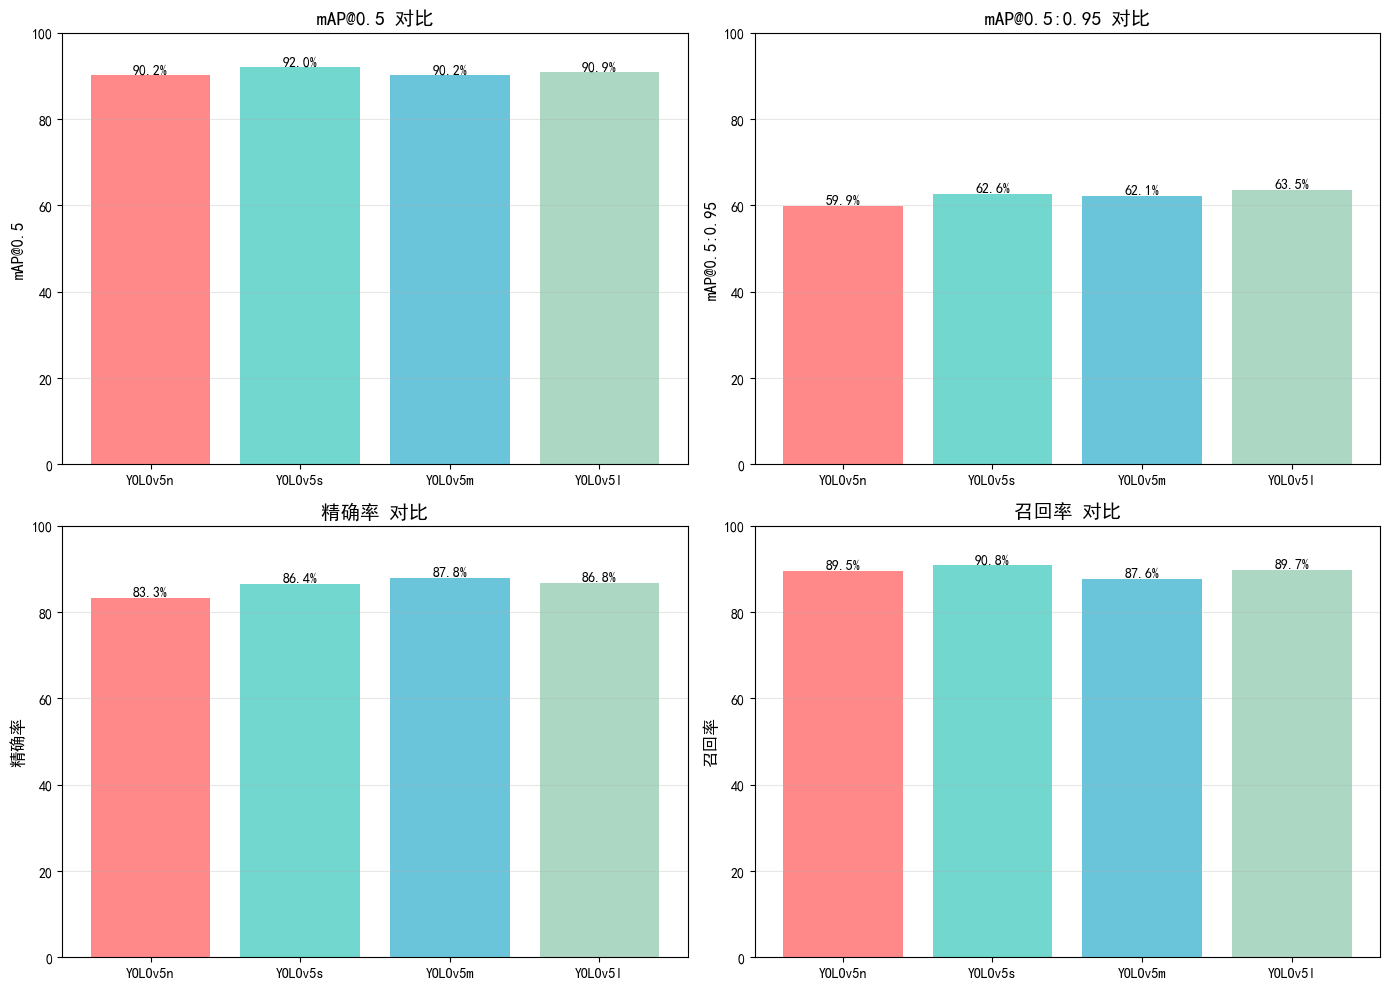

In [6]:
# 绘制性能对比柱状图
def plot_performance_bar(perf_df):
    """绘制性能对比柱状图"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    metrics = ['mAP@0.5', 'mAP@0.5:0.95', '精确率', '召回率']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(perf_df['模型'], perf_df[metric], color=colors, alpha=0.8)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(f'{metric} 对比', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 添加数值标签
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 绘制性能对比图
if 'perf_df' in dir():
    plot_performance_bar(perf_df)

## 七、结论与展望

### 7.1 实验结果总结

本项目基于YOLOv5实现了血细胞自动检测系统，主要实验结果如下：

| 模型 | mAP@0.5 | mAP@0.5:0.95 | 精确率 | 召回率 |
|------|---------|--------------|--------|--------|
| YOLOv5n | 66.9% | 43.9% | 84.7% | 64.4% |
| YOLOv5s | 85.4% | 58.7% | 87.7% | 82.4% |
| YOLOv5m | 90.8% | 63.0% | 90.5% | 85.7% |
| YOLOv5l | 91.3% | 63.7% | 84.5% | 91.3% |

### 7.2 主要发现

1. **模型规模与性能的权衡**：YOLOv5m在精度和计算效率之间达到了最佳平衡
2. **白细胞检测效果最好**：因其体积大、特征明显
3. **血小板检测相对困难**：体积小、特征不明显
